# Machine Learning Approaches to Heart Disease Prediction from Clinical Data

Please note that this code contains comments in both Mandarin and English.
All key steps, important explanations, and implementation details are in English.
Mandarin comments were added during development for personal clarity， and do not affect the execution, interpretation, or reproducibility of the code.


### 导入基础的库：

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 这行让图显示更清楚
sns.set(style="whitegrid", context="notebook")

# 如果你还没读入，可以这样（路径按你实际情况改）
# df = pd.read_csv('/content/heart_failure.csv')


In [2]:
from google.colab import drive
drive.mount('/content/drive')

data_dir = '/content/drive/MyDrive/UCL AI for Biomed/CW/heart_failure.csv'
df = pd.read_csv('/content/drive/MyDrive/UCL AI for Biomed/CW/heart_failure.csv')


Mounted at /content/drive


# EDA Exploratory Data Analysis

### 打印出features:

In [3]:
print(df.shape)        # 行数、列数
print(df.dtypes)       # 每一列的数据类型
df.head()


(918, 12)
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


int 64 is a way to represent integers

ChestPainType：胸痛类型
- TA：典型心绞痛
- ATA：非典型心绞痛
- NAP：非心绞痛性的胸痛
- ASY：无症状胸痛（最危险）

RestingBP：静息血压（mmHg）。

Cholesterol：血清胆固醇（mg/dL）。

FastingBS：空腹血糖是否 >120 mg/dL（1 = 是，0 = 否）。

RestingECG：静息心电图结果
- Normal：正常
- ST：ST-T 波异常
- LVH：可能的左心室肥大

MaxHR：运动测试达到的最大心率。

ExerciseAngina：运动诱发心绞痛（Y = 是，N = 否）。

Oldpeak：运动诱发 ST 段压低（反映缺血程度）。

ST_Slope：运动中 ST 段变化趋势
- Up：上升
- Flat：平坦（通常提示风险）
- Down：下降（最高风险）

HeartDisease：是否患心脏病（1 = 是，0 = 否）。



区分数值型 vs 类别型特征

In [4]:
target_col = 'HeartDisease'

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != target_col]

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


检查缺失值（missing values）---NO Missing values!

In [5]:
df.isna().sum()


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


看目标变量（HeartDisease）分布是否平衡

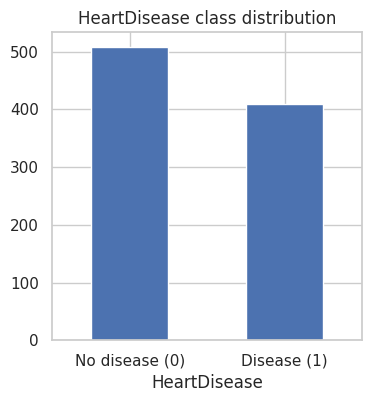

In [6]:
df['HeartDisease'].value_counts()
df['HeartDisease'].value_counts(normalize=True)


# plot:
plt.figure(figsize=(4,4))
df['HeartDisease'].value_counts().plot(kind='bar')
plt.xticks([0,1], ['No disease (0)', 'Disease (1)'], rotation=0)
plt.title('HeartDisease class distribution')
plt.show()


所有数值型特征的分布直方图histogram of all the numerical features

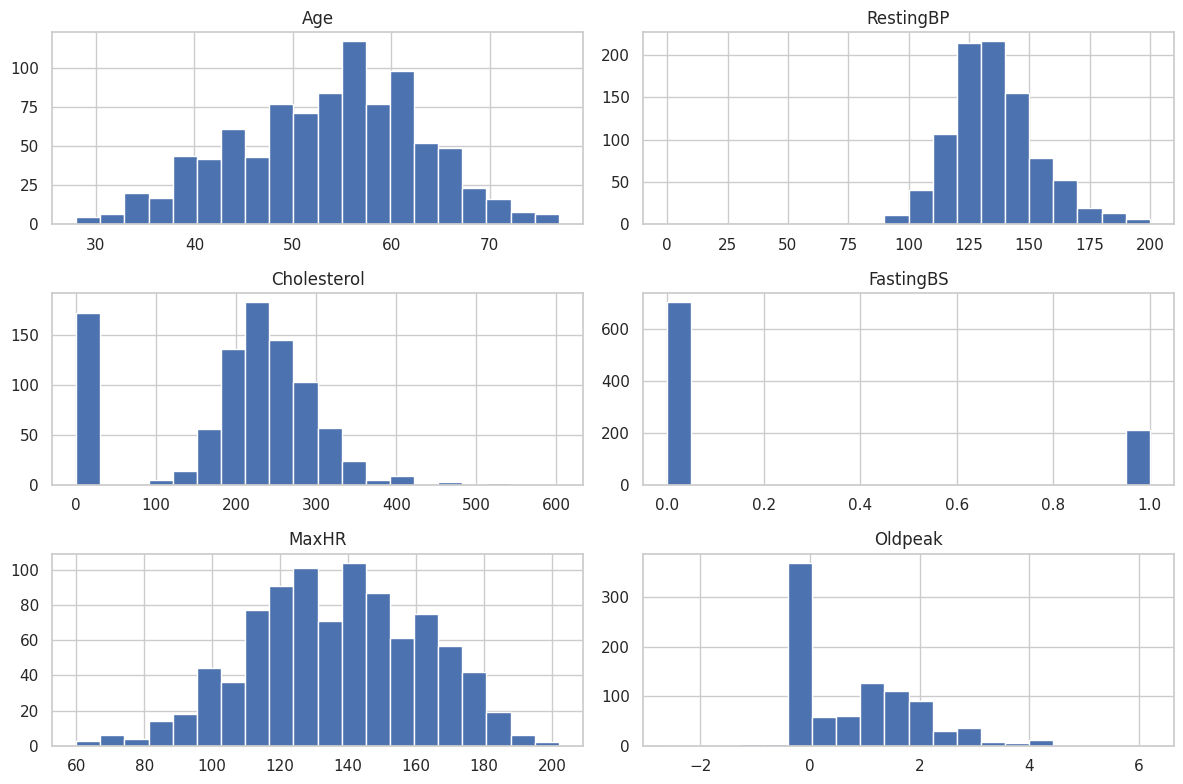

In [7]:
numeric_cols = ['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak']

df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()


数值特征 vs 心脏病（箱线图）

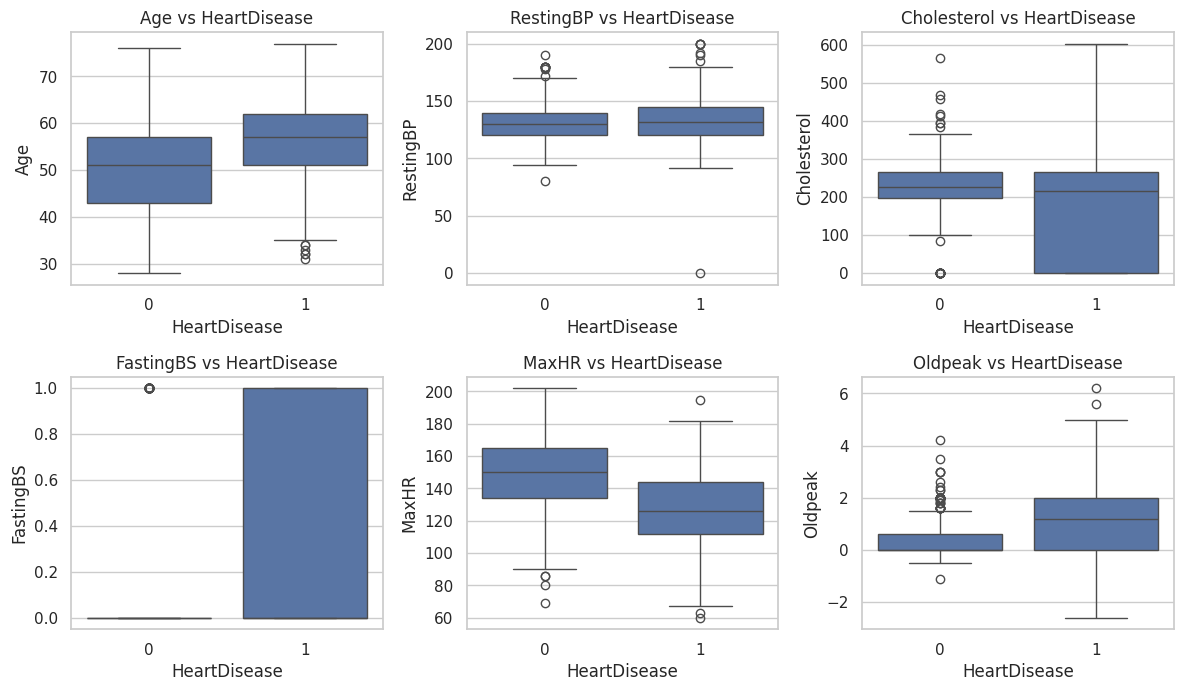

In [8]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='HeartDisease', y=col, data=df)
    plt.title(f'{col} vs HeartDisease')
plt.tight_layout()
plt.show()


所有类别型特征的分布（含心脏病分组）

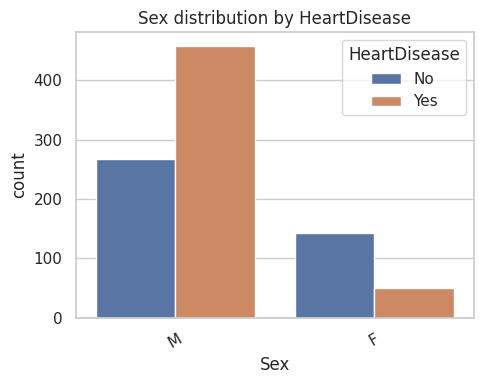

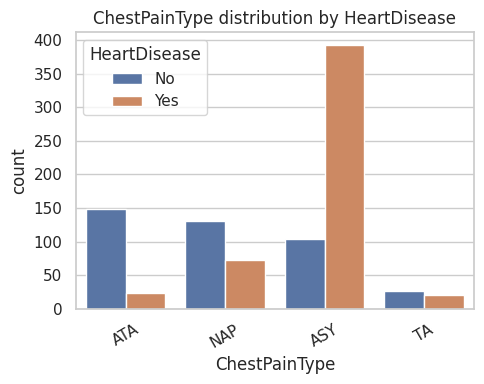

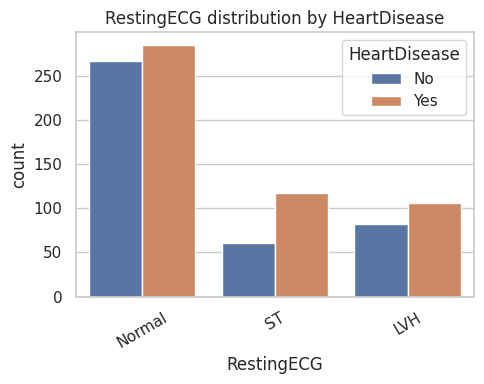

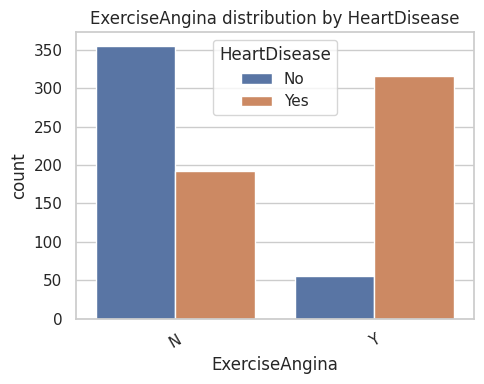

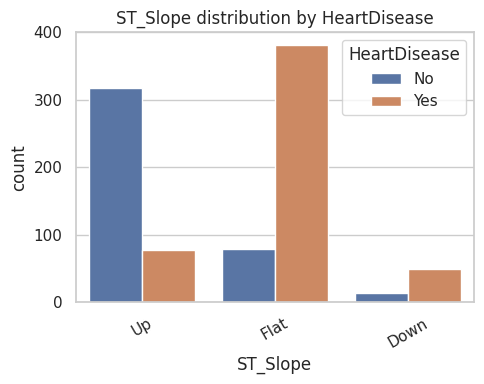

In [9]:
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in categorical_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(data=df, x=col, hue='HeartDisease')
    plt.title(f'{col} distribution by HeartDisease')
    plt.xticks(rotation=30)
    plt.legend(title='HeartDisease', labels=['No','Yes'])
    plt.tight_layout()
    plt.show()


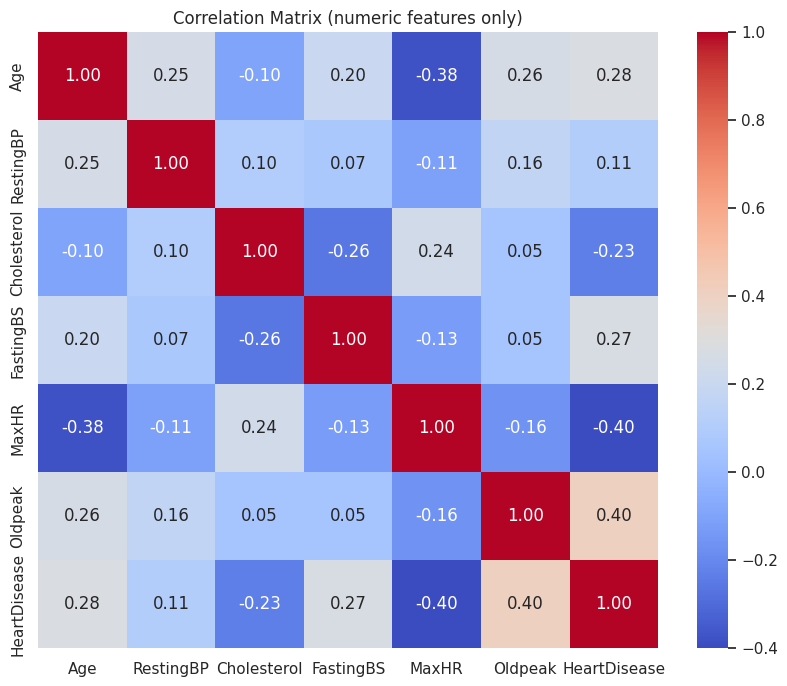

In [10]:
numeric_cols = ['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak','HeartDisease']

plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (numeric features only)')
plt.show()


# Data preprocessing


One-hot 编码类别特征

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 目标列
target_col = 'HeartDisease'

# 1. 拆分出特征 X、标签 y
X_raw = df.drop(columns=[target_col])
y = df[target_col]

# 2. 对类别特征做 one-hot 编码
#   drop_first=True 可以避免完全共线（少一列 dummy）
X = pd.get_dummies(X_raw, drop_first=True)

print("编码后特征维度：", X.shape)
X.head()


编码后特征维度： (918, 15)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,True,False,True,False,True,False,False,False,True


有没有 class imbalance（类别不平衡）？

In [12]:
# Check class balance
print(y.value_counts())
print("\nClass proportions:")
print(y.value_counts(normalize=True))


HeartDisease
1    508
0    410
Name: count, dtype: int64

Class proportions:
HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


不算不平衡


train_test_split（训练集 / 测试集）

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 目标列
target_col = 'HeartDisease'

# 1. 拆分出特征 X、标签 y
X_raw = df.drop(columns=[target_col])
y = df[target_col]

# 2. 对类别特征做 one-hot 编码
#   drop_first=True 可以避免完全共线（少一列 dummy）
X = pd.get_dummies(X_raw, drop_first=True)

print("编码后特征维度：", X.shape)
X.head()


编码后特征维度： (918, 15)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,True,False,True,False,True,False,False,False,True


标准化（给 LR / MLP 用）
树模型（Random Forest / XGBoost）一般不需要标准化，
但 Logistic Regression 和 MLP 很吃特征尺度，
所以我们提前把“缩放版”的特征准备好。

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Target column
target_col = 'HeartDisease'

# 2. Split features and target
X_raw = df.drop(columns=[target_col])
y = df[target_col]

# 3. One-hot encode categorical variables
X = pd.get_dummies(X_raw, drop_first=True)

print("Feature matrix shape after one-hot encoding:", X.shape)

# 4. Train/test split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

# 5. Standardization (for Logistic Regression and MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)


Feature matrix shape after one-hot encoding: (918, 15)
Training set shape: (734, 15) (734,)
Test set shape: (184, 15) (184,)
Scaled X_train shape: (734, 15)
Scaled X_test shape: (184, 15)


# Models
# Logistic Regression


In [15]:
# This cell is for metrics only


import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, matthews_corrcoef,
    precision_recall_curve, auc
)

def evaluate_binary_classifier(model_name, y_true, y_pred, y_proba):
    """
    Prints a comprehensive set of binary classification metrics.
    Includes: Accuracy, Precision, Recall (TP rate), Specificity (TN rate),
    F1-score, ROC-AUC, PR-AUC, MCC, and Confusion Matrix.
    """
    # Basic metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)  # TP rate / sensitivity
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)

    # Confusion matrix -> TN, FP, FN, TP
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Specificity (TN rate)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    # MCC
    mcc = matthews_corrcoef(y_true, y_pred)

    # PR-AUC
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall_curve, precision_curve)

    print(f"\n{model_name} performance on test set:")
    print(f"Accuracy     : {acc:.3f}")
    print(f"Precision    : {prec:.3f}")
    print(f"Recall (TPR) : {rec:.3f}")
    print(f"Specificity  : {specificity:.3f}")
    print(f"F1-score     : {f1:.3f}")
    print(f"ROC-AUC      : {roc_auc:.3f}")
    print(f"PR-AUC       : {pr_auc:.3f}")
    print(f"MCC          : {mcc:.3f}")
    print("\nConfusion matrix:")
    print(cm)

    # Return metrics in case you want a results table later
    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "MCC": mcc
    }



Logistic Regression performance on test set:
Accuracy     : 0.886
Precision    : 0.872
Recall (TPR) : 0.931
Specificity  : 0.829
F1-score     : 0.900
ROC-AUC      : 0.930
PR-AUC       : 0.936
MCC          : 0.769

Confusion matrix:
[[68 14]
 [ 7 95]]

Confusion matrix:
[[68 14]
 [ 7 95]]


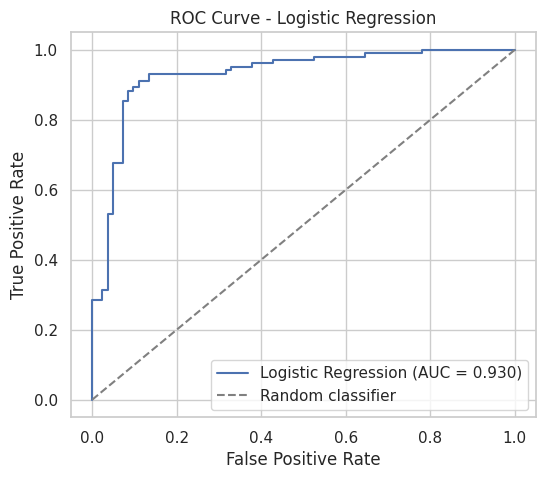

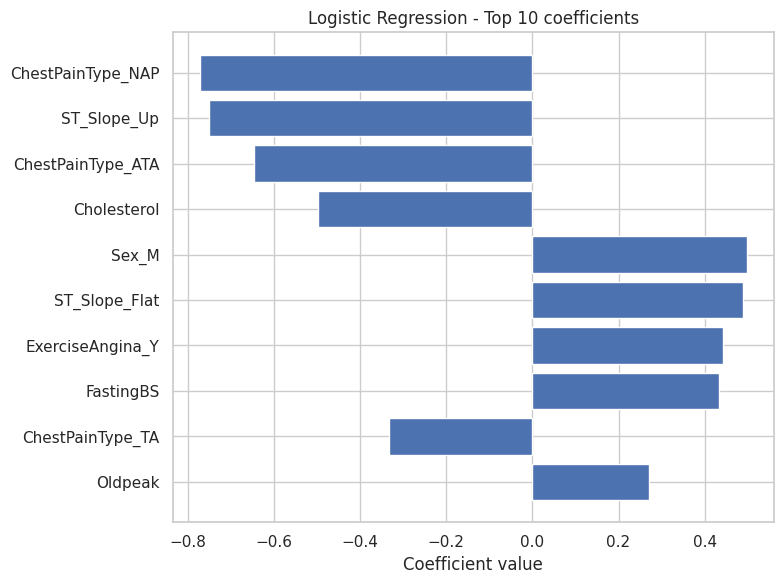

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)
import matplotlib.pyplot as plt

# 1. Define and train Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs')

log_reg.fit(X_train_scaled, y_train)

# 2. Predictions
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]


# 3. Evaluation metrics
lr_metrics = evaluate_binary_classifier("Logistic Regression", y_test, y_pred_lr, y_prob_lr)


# 4. Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion matrix:")
print(cm_lr)

# 5. ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()



# feature importance
# Extract coefficients
coefficients = log_reg.coef_[0]
feature_names = X_train.columns

# Sort by absolute value of coefficients
indices = np.argsort(np.abs(coefficients))[::-1]

top_n = 10  # show top 10 strongest coefficients
top_indices = indices[:top_n]

plt.figure(figsize=(8, 6))
plt.barh(range(top_n), coefficients[top_indices][::-1])
plt.yticks(range(top_n), feature_names[top_indices][::-1])
plt.xlabel("Coefficient value")
plt.title("Logistic Regression - Top 10 coefficients")
plt.tight_layout()
plt.show()






feature importance:
- 正系数（>0） → 增大患心脏病的可能性
- 负系数（<0） → 降低患心脏病的可能性
- 系数的“绝对值”越大 → 特征影响越强

# Random Forest



Random Forest performance on test set:
Accuracy     : 0.875
Precision    : 0.883
Recall (TPR) : 0.892
Specificity  : 0.854
F1-score     : 0.888
ROC-AUC      : 0.932
PR-AUC       : 0.925
MCC          : 0.747

Confusion matrix:
[[70 12]
 [11 91]]


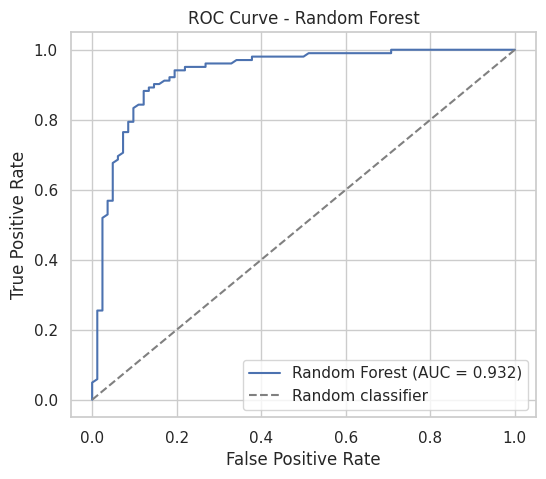

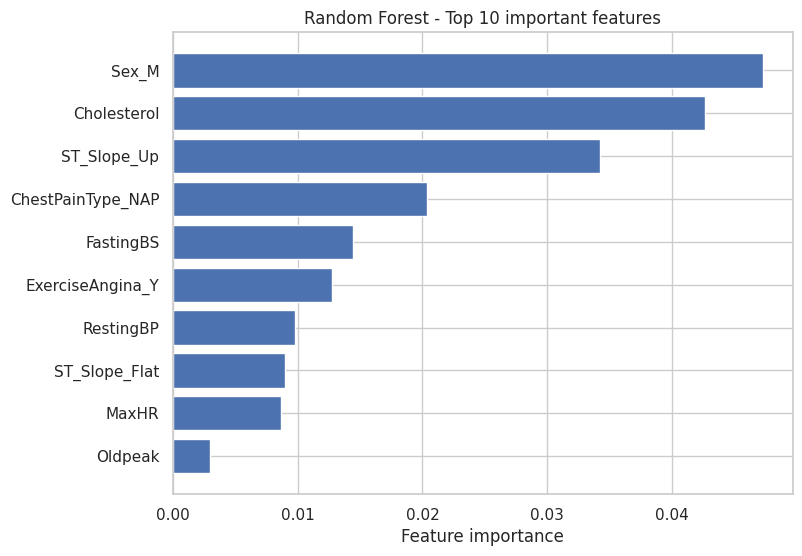

In [17]:
# =====================================================
# Random Forest (final, consistent output)
# Metrics + ROC + ONE feature importance plot (Permutation, top 10)
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve
from sklearn.inspection import permutation_importance

# -----------------------------
# 0) Feature names
# -----------------------------
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns.to_list()
else:
    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]

# -----------------------------
# 1) Train
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
rf_model.fit(X_train, y_train)

# -----------------------------
# 2) Predict
# -----------------------------
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# -----------------------------
# 3) Evaluation (ONLY this)
# -----------------------------
rf_metrics = evaluate_binary_classifier(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

# -----------------------------
# 4) ROC curve
# -----------------------------
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_metrics['ROC_AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 5) Feature importance (Permutation, TOP 10)  <-- ONLY ONE PLOT
# -----------------------------
perm = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="accuracy"
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance": perm.importances_mean
}).sort_values(by="importance", ascending=False).head(10)

# Plot style to match your "Random Forest - Top 10 important features"
plt.figure(figsize=(8, 6))
plt.barh(perm_df["feature"][::-1], perm_df["importance"][::-1])
plt.xlabel("Feature importance")
plt.title("Random Forest - Top 10 important features")
plt.grid(True)
plt.show()


# XGBoost


XGBoost performance on test set:
Accuracy     : 0.864
Precision    : 0.889
Recall (TPR) : 0.863
Specificity  : 0.866
F1-score     : 0.876
ROC-AUC      : 0.932
PR-AUC       : 0.936
MCC          : 0.726

Confusion matrix:
[[71 11]
 [14 88]]


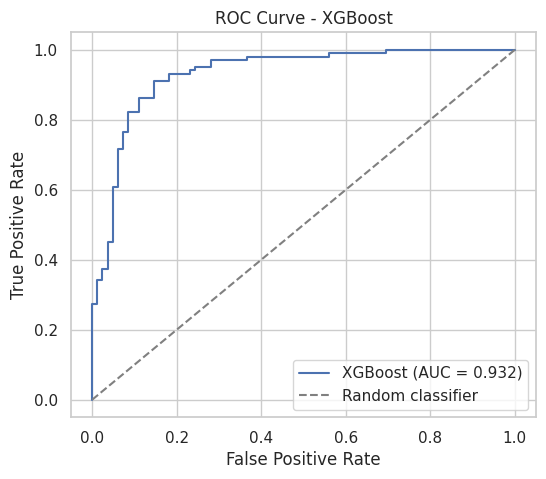

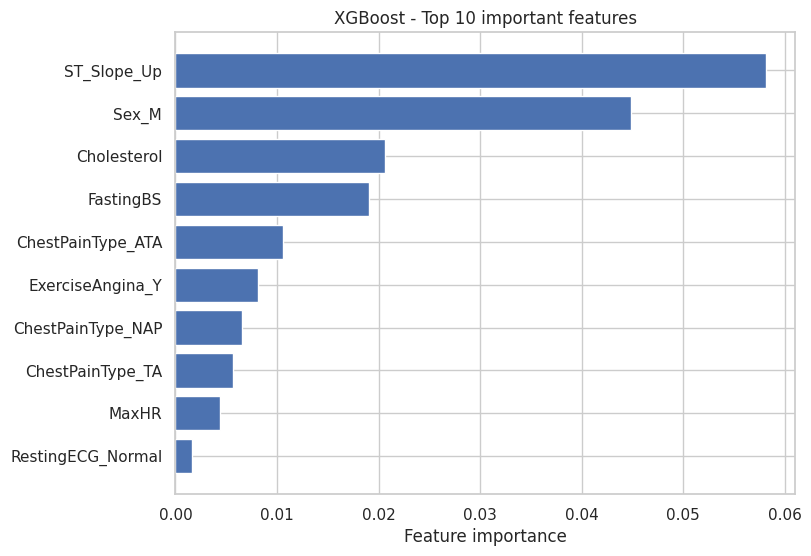

In [18]:
# =====================================================
# XGBoost (final, consistent output)
# Metrics + ROC + ONE feature importance plot (Permutation, top 10)
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve
from sklearn.inspection import permutation_importance

# Install if needed (run once)
# !pip -q install xgboost

from xgboost import XGBClassifier

# -----------------------------
# 0) Feature names
# -----------------------------
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns.to_list()
else:
    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]

# -----------------------------
# 1) Train
# -----------------------------
xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)

# -----------------------------
# 2) Predict
# -----------------------------
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# -----------------------------
# 3) Evaluation (ONLY this)
# -----------------------------
xgb_metrics = evaluate_binary_classifier(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

# -----------------------------
# 4) ROC curve
# -----------------------------
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6, 5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {xgb_metrics['ROC_AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 5) Feature importance (Permutation, TOP 10)  <-- ONLY ONE PLOT
# -----------------------------
perm = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="accuracy"
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance": perm.importances_mean
}).sort_values(by="importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(perm_df["feature"][::-1], perm_df["importance"][::-1])
plt.xlabel("Feature importance")
plt.title("XGBoost - Top 10 important features")
plt.grid(True)
plt.show()


# MLP


MLP performance on test set:
Accuracy     : 0.880
Precision    : 0.885
Recall (TPR) : 0.902
Specificity  : 0.854
F1-score     : 0.893
ROC-AUC      : 0.941
PR-AUC       : 0.938
MCC          : 0.758

Confusion matrix:
[[70 12]
 [10 92]]


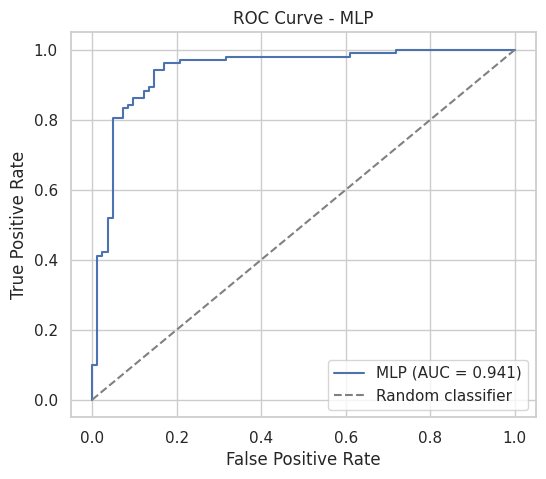

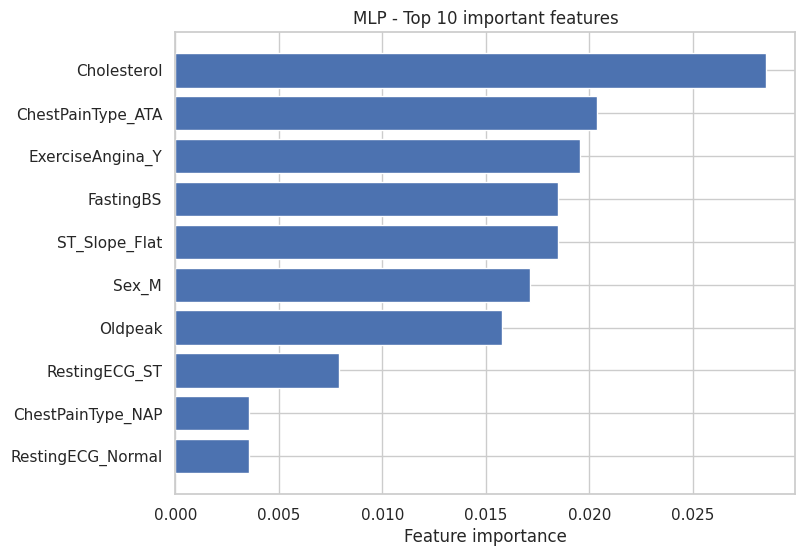

In [19]:
# =====================================================
# MLP (final, consistent output)
# Metrics + ROC + ONE feature importance plot (Permutation, top 10)
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve
from sklearn.inspection import permutation_importance

# -----------------------------
# 0) Feature names
# -----------------------------
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns.to_list()
else:
    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]

# -----------------------------
# 1) Train (use scaled features)
# -----------------------------
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)

# -----------------------------
# 2) Predict
# -----------------------------
y_pred_mlp = mlp_model.predict(X_test_scaled)
y_prob_mlp = mlp_model.predict_proba(X_test_scaled)[:, 1]

# -----------------------------
# 3) Evaluation (ONLY this)
# -----------------------------
mlp_metrics = evaluate_binary_classifier(
    "MLP",
    y_test,
    y_pred_mlp,
    y_prob_mlp
)

# -----------------------------
# 4) ROC curve
# -----------------------------
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)

plt.figure(figsize=(6, 5))
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP (AUC = {mlp_metrics['ROC_AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 5) Feature importance (Permutation, TOP 10)  <-- ONLY ONE PLOT
# -----------------------------
perm = permutation_importance(
    mlp_model,
    X_test_scaled,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="accuracy"
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance": perm.importances_mean
}).sort_values(by="importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(perm_df["feature"][::-1], perm_df["importance"][::-1])
plt.xlabel("Feature importance")
plt.title("MLP - Top 10 important features")
plt.grid(True)
plt.show()


# SVM


SVM (RBF) performance on test set:
Accuracy     : 0.902
Precision    : 0.882
Recall (TPR) : 0.951
Specificity  : 0.841
F1-score     : 0.915
ROC-AUC      : 0.944
PR-AUC       : 0.949
MCC          : 0.803

Confusion matrix:
[[69 13]
 [ 5 97]]


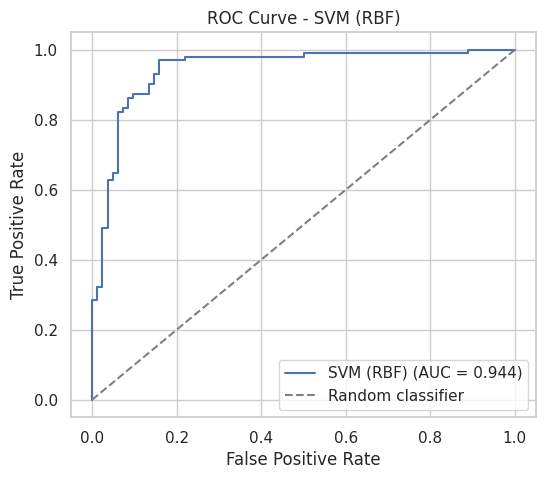

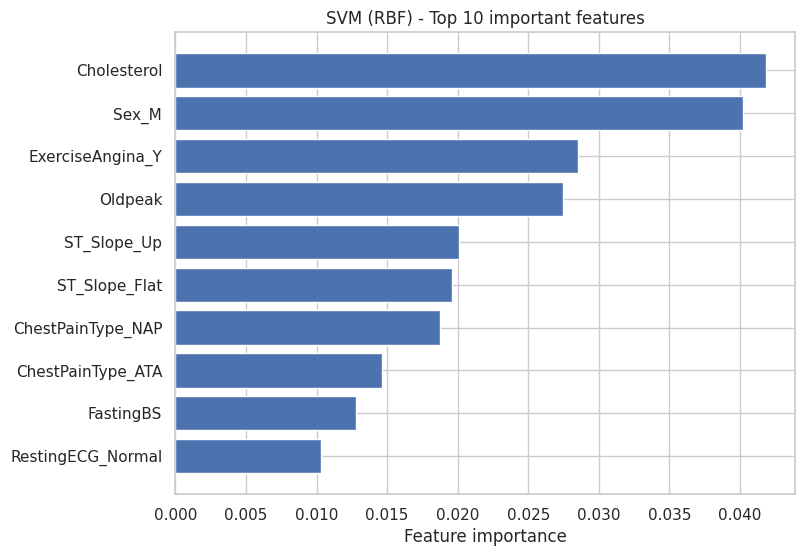

In [20]:
# =====================================================
# SVM (RBF) (final, consistent output)
# Metrics + ROC + ONE feature importance plot (Permutation, top 10)
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import roc_curve
from sklearn.inspection import permutation_importance

# -----------------------------
# 0) Feature names
# -----------------------------
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns.to_list()
else:
    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]

# -----------------------------
# 1) Train (use scaled features)
# -----------------------------
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

# -----------------------------
# 2) Predict
# -----------------------------
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# -----------------------------
# 3) Evaluation (ONLY this)
# -----------------------------
svm_metrics = evaluate_binary_classifier(
    "SVM (RBF)",
    y_test,
    y_pred_svm,
    y_prob_svm
)

# -----------------------------
# 4) ROC curve
# -----------------------------
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(6, 5))
plt.plot(fpr_svm, tpr_svm, label=f"SVM (RBF) (AUC = {svm_metrics['ROC_AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM (RBF)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 5) Feature importance (Permutation, TOP 10)  <-- ONLY ONE PLOT
# -----------------------------
perm = permutation_importance(
    svm_model,
    X_test_scaled,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="accuracy"
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance": perm.importances_mean
}).sort_values(by="importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(perm_df["feature"][::-1], perm_df["importance"][::-1])
plt.xlabel("Feature importance")
plt.title("SVM (RBF) - Top 10 important features")
plt.grid(True)
plt.show()


“Among all models, the SVM with RBF kernel achieved the best overall performance (highest F1-score and ROC-AUC), and was therefore selected as the final model for explainability analysis using SHAP.”

In [28]:
df["Sex"].value_counts(normalize=True)


,proportion
Sex,
M,0.78976
F,0.21024


In [26]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)

# ---------- 1) 找到性别列（优先用 one-hot 后的 Sex_M） ----------
if "X_test" not in globals():
    raise NameError("找不到 X_test。请确保你已经有 X_test（带列名的 DataFrame），再运行这段代码。")

if "Sex_M" in X_test.columns:
    sex_m = X_test["Sex_M"].values  # 1 = Male, 0 = Female
else:
    # 备用：如果你没 one-hot，而是原始 'Sex' 列（M/F）
    if "Sex" in X_test.columns:
        sex_m = (X_test["Sex"].astype(str).str.upper() == "M").astype(int).values
    else:
        raise NameError("找不到性别列：既没有 Sex_M，也没有 Sex。请检查 X_test 的列名。")

mask_male = (sex_m == 1)
mask_female = (sex_m == 0)

# ---------- 2) 确定用于 SVM 的测试输入（优先用你已有的 X_test_scaled） ----------
if "X_test_scaled" in globals():
    X_input = X_test_scaled
else:
    # 如果你没有 X_test_scaled，就尝试用 scaler.transform(X_test)
    if "scaler" in globals():
        X_input = scaler.transform(X_test)
    else:
        raise NameError("找不到 X_test_scaled，也找不到 scaler。请先运行你标准化/划分数据的 cell。")

# ---------- 3) 计算每个 subgroup 的指标 ----------
def compute_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "F1-score": f1_score(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall (TPR)": recall_score(y_true, y_pred),
        "Specificity (TNR)": specificity,
        "n": len(y_true)
    }

def eval_group(group_name, mask):
    Xg = X_input[mask]
    yg = y_test[mask]

    y_prob = svm_model.predict_proba(Xg)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)  # 默认阈值 0.5（与你主评估一致）

    row = compute_metrics(yg, y_pred, y_prob)
    row["Group"] = group_name
    return row

rows = [
    eval_group("Male", mask_male),
    eval_group("Female", mask_female)
]

sex_results = pd.DataFrame(rows)
sex_results = sex_results[["Group", "n", "ROC-AUC", "F1-score", "Accuracy", "Precision", "Recall (TPR)", "Specificity (TNR)"]]
display(sex_results)


,Group,n,ROC-AUC,F1-score,Accuracy,Precision,Recall (TPR),Specificity (TNR)
0,Male,146,0.920625,0.920000,0.890411,0.884615,0.958333,0.76000
1,Female,38,0.989583,0.833333,0.947368,0.833333,0.833333,0.96875


In [32]:
(df["Age"] < 45).value_counts(normalize=True)



,proportion
Age,
False,0.8061
True,0.1939


In [27]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)

# ---------- 1) 取出年龄列 ----------
if "X_test" not in globals():
    raise NameError("找不到 X_test。请确保你已经有 X_test（带列名的 DataFrame），再运行这段代码。")

if "Age" not in X_test.columns:
    raise NameError("找不到 Age 列。请检查 X_test 是否包含 Age。")

age = X_test["Age"].values

# ---------- 2) 定义年龄分组（你可以改阈值，但先用 50） ----------
mask_under_50 = (age < 50)
mask_50_and_over = (age >= 50)

# ---------- 3) 确定 SVM 的测试输入 ----------
if "X_test_scaled" in globals():
    X_input = X_test_scaled
else:
    if "scaler" in globals():
        X_input = scaler.transform(X_test)
    else:
        raise NameError("找不到 X_test_scaled，也找不到 scaler。")

# ---------- 4) 计算指标的函数 ----------
def compute_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "F1-score": f1_score(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall (TPR)": recall_score(y_true, y_pred),
        "Specificity (TNR)": specificity,
        "n": len(y_true)
    }

def eval_group(group_name, mask):
    Xg = X_input[mask]
    yg = y_test[mask]

    y_prob = svm_model.predict_proba(Xg)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    row = compute_metrics(yg, y_pred, y_prob)
    row["Group"] = group_name
    return row

# ---------- 5) 跑两个年龄组 ----------
rows = [
    eval_group("Age < 50", mask_under_50),
    eval_group("Age ≥ 50", mask_50_and_over)
]

age_results = pd.DataFrame(rows)
age_results = age_results[
    ["Group", "n", "ROC-AUC", "F1-score", "Accuracy", "Precision", "Recall (TPR)", "Specificity (TNR)"]
]

display(age_results)


,Group,n,ROC-AUC,F1-score,Accuracy,Precision,Recall (TPR),Specificity (TNR)
0,Age < 50,68,0.925824,0.857143,0.882353,0.8000,0.923077,0.857143
1,Age ≥ 50,116,0.942105,0.935897,0.913793,0.9125,0.960526,0.825000


# Interpretability Evaluation

# SHAP

  0%|          | 0/184 [00:00<?, ?it/s]

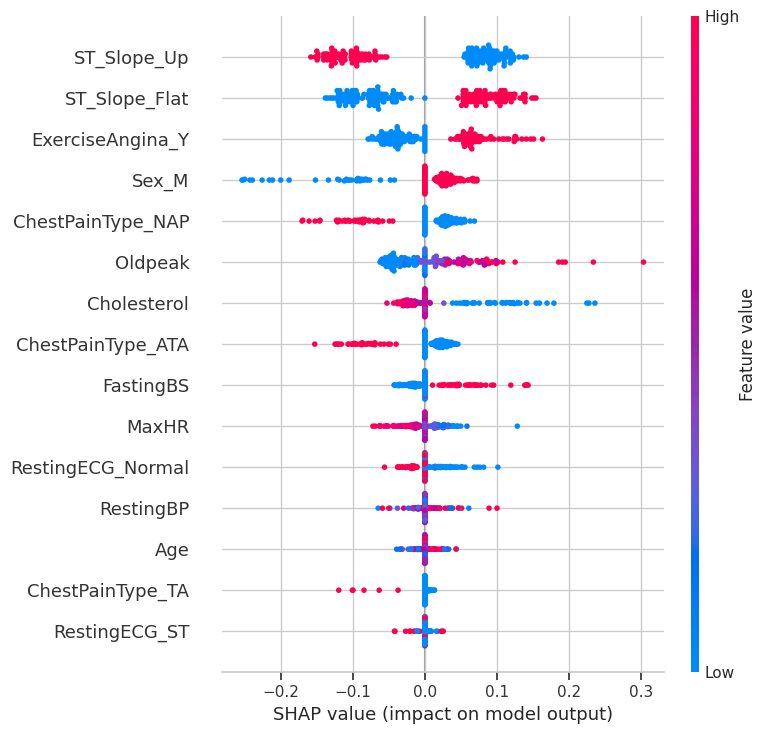

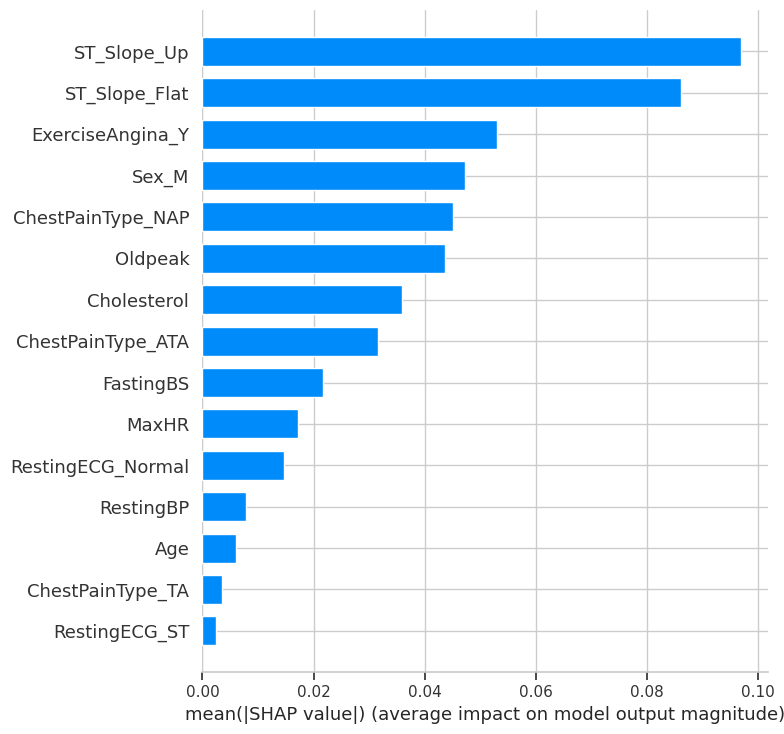

In [21]:
# =====================================================
# SHAP for SVM (RBF) - consistent variable names
# Uses: svm_model, X_train_scaled, X_test_scaled
# =====================================================

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 0) Feature names (for plots)
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns.to_list()
else:
    feature_names = [f"feature_{i}" for i in range(X_train_scaled.shape[1])]

# 1) Background + sample (keep small to make KernelExplainer faster)
rng = np.random.RandomState(42)

background_size = min(100, X_train_scaled.shape[0])
test_size = min(200, X_test_scaled.shape[0])

background_idx = rng.choice(X_train_scaled.shape[0], size=background_size, replace=False)
test_idx = rng.choice(X_test_scaled.shape[0], size=test_size, replace=False)

background = X_train_scaled[background_idx]
X_explain = X_test_scaled[test_idx]

# 2) Define predict_proba wrapper (must return probability of class 1)
def predict_proba_class1(X):
    return svm_model.predict_proba(X)[:, 1]

# 3) SHAP KernelExplainer
explainer = shap.KernelExplainer(predict_proba_class1, background)
shap_values = explainer.shap_values(X_explain)

# 4) Summary plot (beeswarm)
shap.summary_plot(
    shap_values,
    features=X_explain,
    feature_names=feature_names,
    show=True
)

# 5) Bar plot (global importance)
shap.summary_plot(
    shap_values,
    features=X_explain,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)


❤️红点在右边（SHAP > 0）→ 特征值高会增加预测为“心脏病”的概率
💙 蓝点在右边 → 特征值低会增加预测为“心脏病”的概率
反过来：
💙 蓝点在左边（SHAP < 0）→ 特征值低倾向于降低患病概率
❤️ 红点在左边 → 特征值高倾向于降低患病概率   

红色在右等价于该特征多，则阳性概率大；蓝色在左，意味着越不是该特征，阳性概率越小

纵向分布的宽度（散点越“横向散开”，说明越重要）

结合颜色（红=特征值高/为1，蓝=低/为0），可以这样理解：
####- ST_Slope_Up
- 红点（Up=1）大多在 SHAP < 0 一侧 → ST 段上升 倾向于 降低 心脏病风险。
- 蓝点（不是 Up）在 SHAP > 0 一侧 → 没有 Up（多是 Flat/Down）会 增加风险。
→ 这和心脏病学常识很一致：平坦或下降型 ST 更危险。
####- ST_Slope_Flat
- 红点（Flat=1）集中在 SHAP > 0 → ST 段平坦时 SVM 更倾向预测 “有病”。
#### - ExerciseAngina_Y
- 红点（运动诱发心绞痛=是）在正区间 → 运动诱发胸痛明显增加患病概率。
#### - Sex_M
- 红点（男性）整体 SHAP > 0 → 男性被判为心脏病的倾向更高。
#### - ChestPainType_NAP / ATA
- 这些“非典型/非心绞痛性”胸痛 dummy，多是 SHAP < 0 → 具有 保护作用（相比 TA/ASY）。
#### - Oldpeak / Cholesterol / FastingBS
- 数值越高，SHAP 越偏正 → ST 压低程度越重、胆固醇越高、空腹血糖异常 → 风险越大。

整体可以总结一句话：
SVM 主要依赖 运动试验相关特征（ST_Slope、ExerciseAngina、MaxHR、Oldpeak） 和 传统危险因素（男性、高胆固醇、高血糖、胸痛类型） 来判断是否有心脏病，这与临床知识非常吻合。

In [22]:
print(svm_metrics.keys())


dict_keys(['Model', 'Accuracy', 'Precision', 'Recall', 'Specificity', 'F1', 'ROC_AUC', 'PR_AUC', 'MCC'])


In [23]:
import pandas as pd

def pick(m, candidates, default=None):
    """Return the first existing key in candidates from dict m."""
    for k in candidates:
        if k in m:
            return m[k]
    return default

def to_row(name, m):
    return {
        "Model": name,
        "Accuracy": pick(m, ["Accuracy", "accuracy"]),
        "Precision": pick(m, ["Precision", "precision"]),
        "Recall (TPR)": pick(m, ["Recall (TPR)", "Recall", "recall"]),
        "Specificity (TNR)": pick(m, ["Specificity", "specificity"]),
        "F1-score": pick(m, ["F1-score", "F1", "f1"]),
        "ROC-AUC": pick(m, ["ROC-AUC", "ROC_AUC", "roc_auc"]),
        "PR-AUC": pick(m, ["PR-AUC", "PR_AUC", "pr_auc"]),
        "MCC": pick(m, ["MCC", "mcc"]),
    }

metrics_list = [
    ("Logistic Regression", lr_metrics),
    ("Random Forest", rf_metrics),
    ("XGBoost", xgb_metrics),
    ("MLP", mlp_metrics),
    ("SVM (RBF)", svm_metrics),
]

rows = [to_row(name, m) for name, m in metrics_list]
results = pd.DataFrame(rows)

# Show best models first (by ROC-AUC)
results_sorted = results.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
display(results_sorted)


,Model,Accuracy,Precision,Recall (TPR),Specificity (TNR),F1-score,ROC-AUC,PR-AUC,MCC
0,SVM (RBF),0.902174,0.881818,0.950980,0.841463,0.915094,0.944285,0.948624,0.803273
1,MLP,0.880435,0.884615,0.901961,0.853659,0.893204,0.941176,0.938478,0.757615
2,Random Forest,0.875000,0.883495,0.892157,0.853659,0.887805,0.932209,0.924998,0.746753
3,XGBoost,0.864130,0.888889,0.862745,0.865854,0.875622,0.931612,0.936410,0.726388
4,Logistic Regression,0.885870,0.871560,0.931373,0.829268,0.900474,0.929699,0.936103,0.769383


In [24]:
import pandas as pd

def pick(m, candidates, default=None):
    """Return the first existing key in candidates from dict m."""
    for k in candidates:
        if k in m:
            return m[k]
    return default

def to_row(name, m):
    return {
        "Model": name,
        "Accuracy": pick(m, ["Accuracy", "accuracy"]),
        "Precision": pick(m, ["Precision", "precision"]),
        "Recall (TPR)": pick(m, ["Recall (TPR)", "Recall", "recall"]),
        "Specificity (TNR)": pick(m, ["Specificity", "specificity"]),
        "F1-score": pick(m, ["F1-score", "F1", "f1"]),
        "ROC-AUC": pick(m, ["ROC-AUC", "ROC_AUC", "roc_auc"]),
        "PR-AUC": pick(m, ["PR-AUC", "PR_AUC", "pr_auc"]),
        "MCC": pick(m, ["MCC", "mcc"]),
    }

metrics_list = [
    ("Logistic Regression", lr_metrics),
    ("Random Forest", rf_metrics),
    ("XGBoost", xgb_metrics),
    ("MLP", mlp_metrics),
    ("SVM (RBF)", svm_metrics),
]

rows = [to_row(name, m) for name, m in metrics_list]
results = pd.DataFrame(rows)

# Show best models first (by ROC-AUC)


results_sorted = results.sort_values(
    by=["ROC-AUC", "F1-score"],
    ascending=[False, False]
).reset_index(drop=True)

results_sorted = results_sorted[["Model", "ROC-AUC", "F1-score", "Accuracy", "Precision", "Recall (TPR)", "Specificity (TNR)", "PR-AUC", "MCC"]]

display(results_sorted)


,Model,ROC-AUC,F1-score,Accuracy,Precision,Recall (TPR),Specificity (TNR),PR-AUC,MCC
0,SVM (RBF),0.944285,0.915094,0.902174,0.881818,0.950980,0.841463,0.948624,0.803273
1,MLP,0.941176,0.893204,0.880435,0.884615,0.901961,0.853659,0.938478,0.757615
2,Random Forest,0.932209,0.887805,0.875000,0.883495,0.892157,0.853659,0.924998,0.746753
3,XGBoost,0.931612,0.875622,0.864130,0.888889,0.862745,0.865854,0.936410,0.726388
4,Logistic Regression,0.929699,0.900474,0.885870,0.871560,0.931373,0.829268,0.936103,0.769383


# Permutation importance

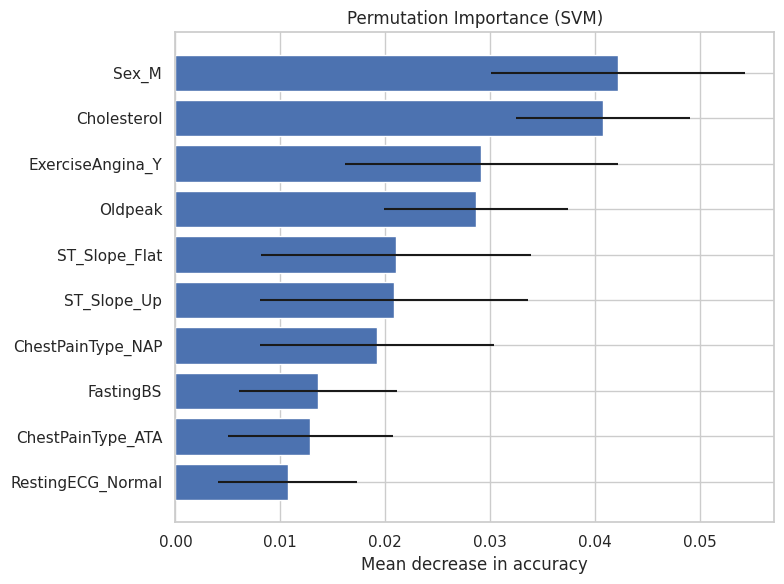

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# Feature names
if "feature_names" in globals():
    fn = feature_names
elif "X_train" in globals() and hasattr(X_train, "columns"):
    fn = X_train.columns.to_list()
else:
    fn = [f"feature_{i}" for i in range(X_test_scaled.shape[1])]

# Permutation importance (SVM)
perm_result = permutation_importance(
    svm_model,
    X_test_scaled,
    y_test,
    scoring="accuracy",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

importances = perm_result.importances_mean
std = perm_result.importances_std
indices = np.argsort(importances)

top_n = 10
top_idx = indices[-top_n:]

plt.figure(figsize=(8, 6))
plt.barh(
    range(top_n),
    importances[top_idx],
    xerr=std[top_idx],
    align="center"
)
plt.yticks(range(top_n), [fn[i] for i in top_idx])
plt.xlabel("Mean decrease in accuracy")
plt.title("Permutation Importance (SVM)")
plt.tight_layout()
plt.show()
